# Import Libraries

In [655]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset

In [656]:
data = pd.read_csv('medical-charges.csv')

# EDA

In [657]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [658]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [659]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [660]:
data = data.drop_duplicates()

In [661]:
numerical_cols = ['age', 'bmi', 'children', 'charges']

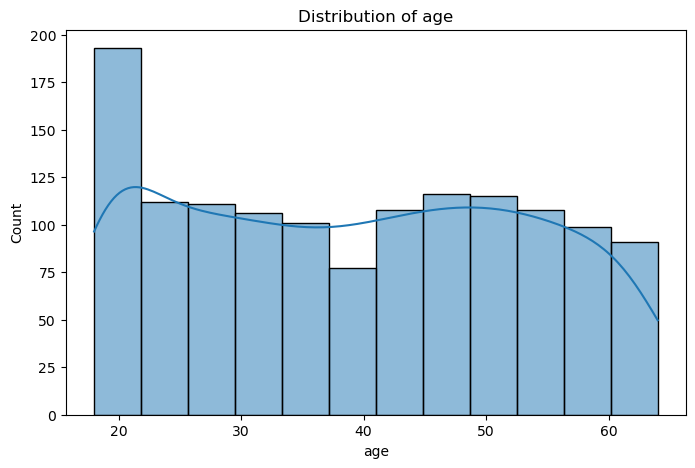

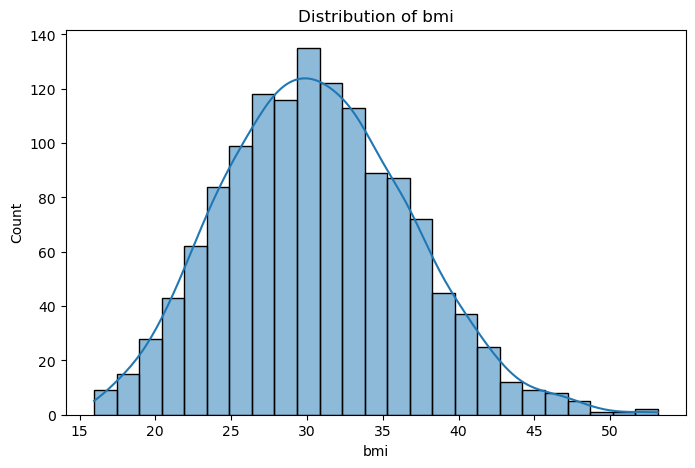

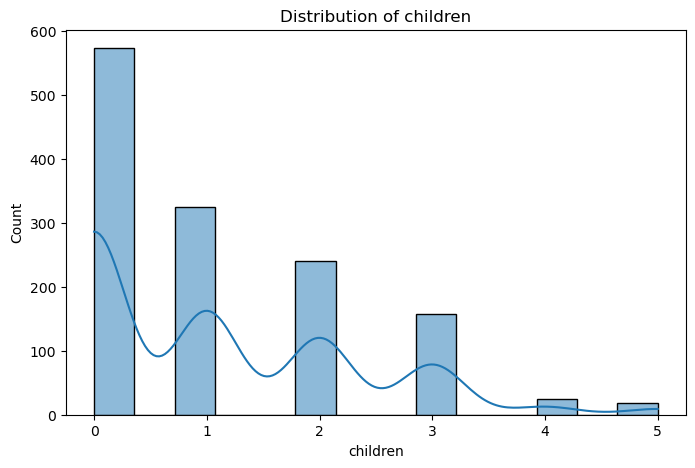

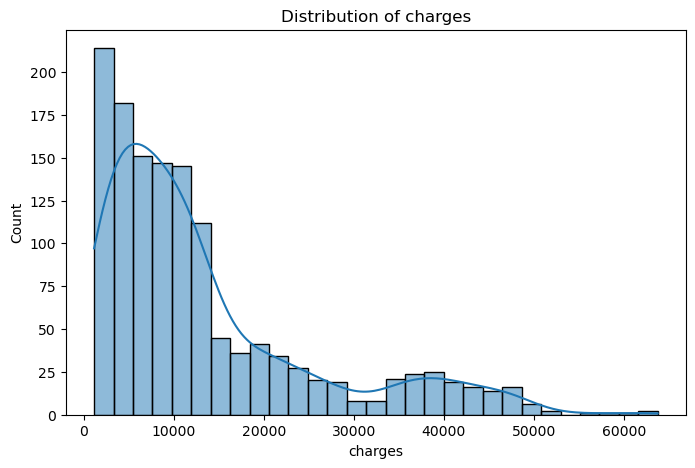

In [662]:
for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

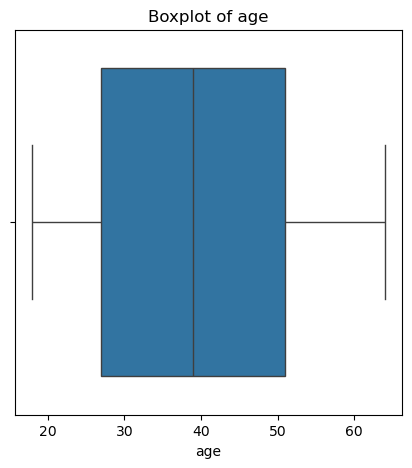

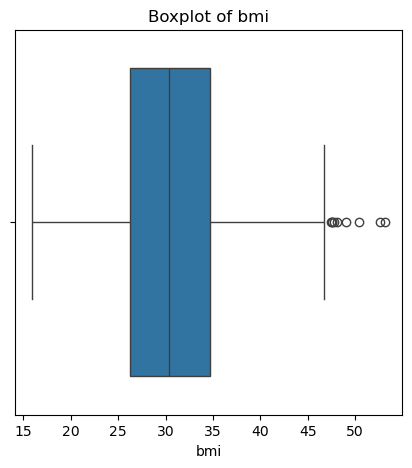

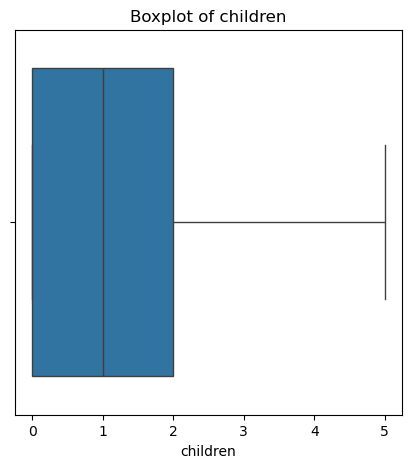

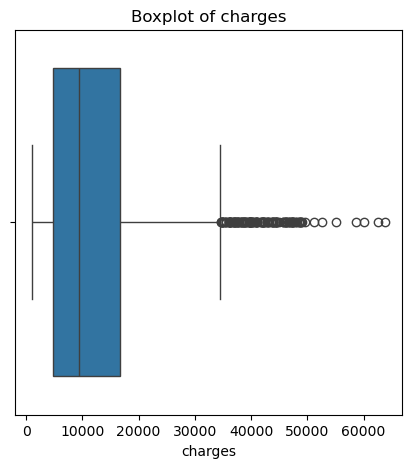

In [663]:
for col in numerical_cols:
    plt.figure(figsize=(5,5))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

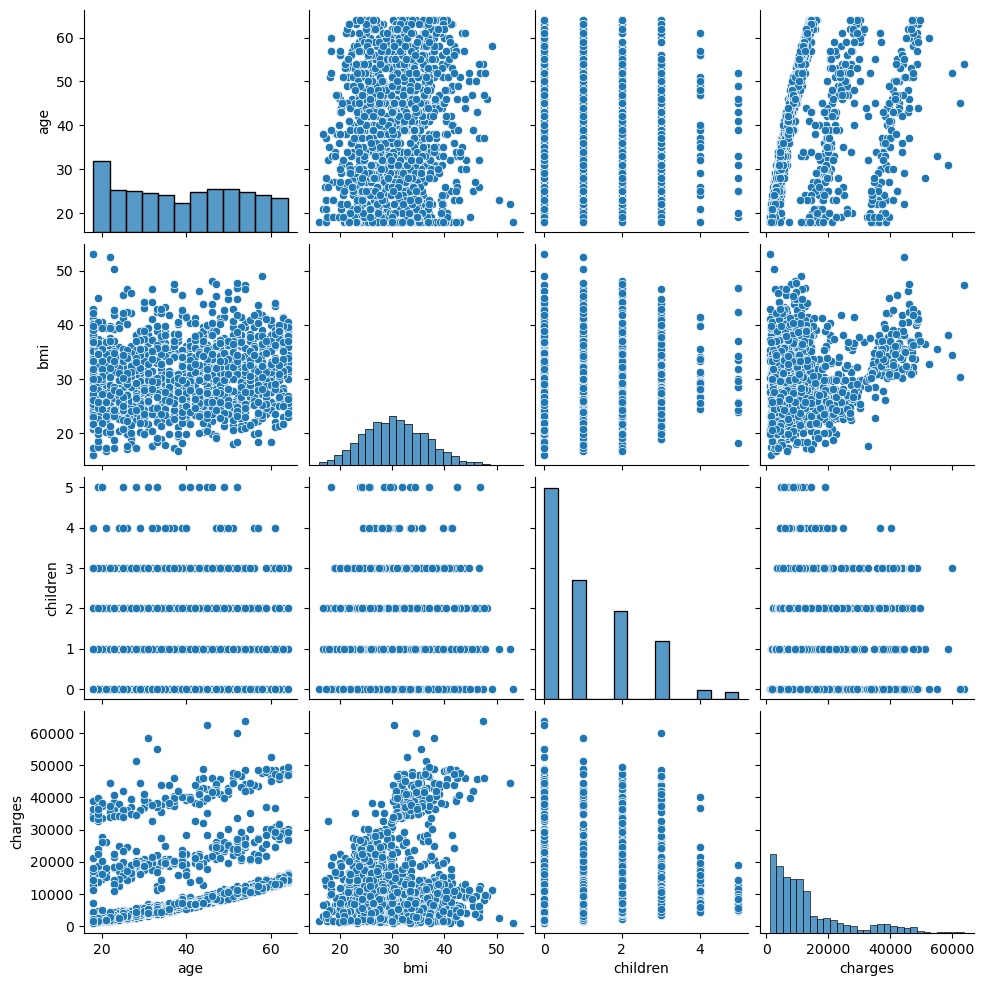

In [664]:
sns.pairplot(data)

<Axes: >

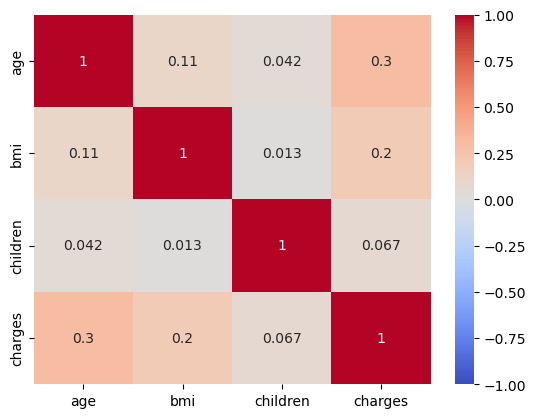

In [665]:
corr_matrix = data.corr(numeric_only=True)
sns.heatmap(corr_matrix,cmap='coolwarm',annot=True,vmin=-1,vmax=1,center=0)

In [666]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### Categorical Data Analysis

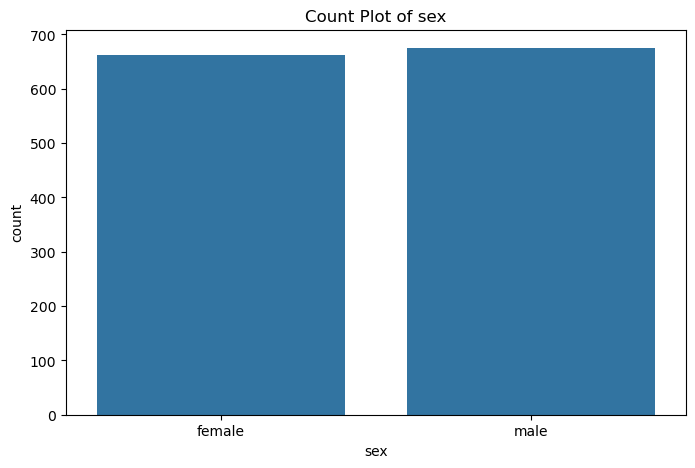

sex
male      675
female    662
Name: count, dtype: int64
sex
male      50.486163
female    49.513837
Name: proportion, dtype: float64


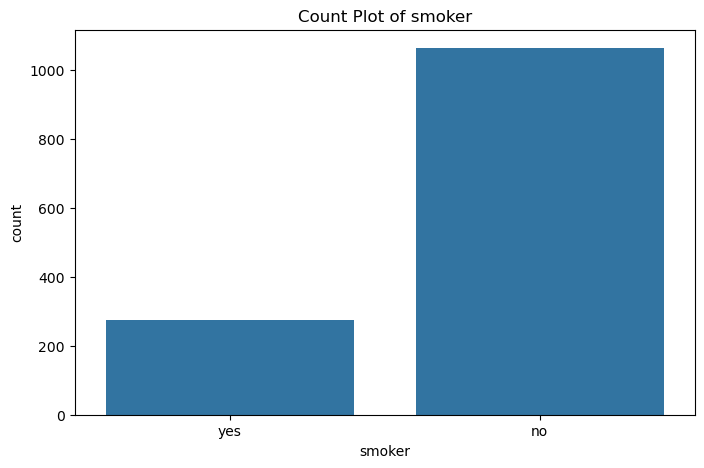

smoker
no     1063
yes     274
Name: count, dtype: int64
smoker
no     79.506358
yes    20.493642
Name: proportion, dtype: float64


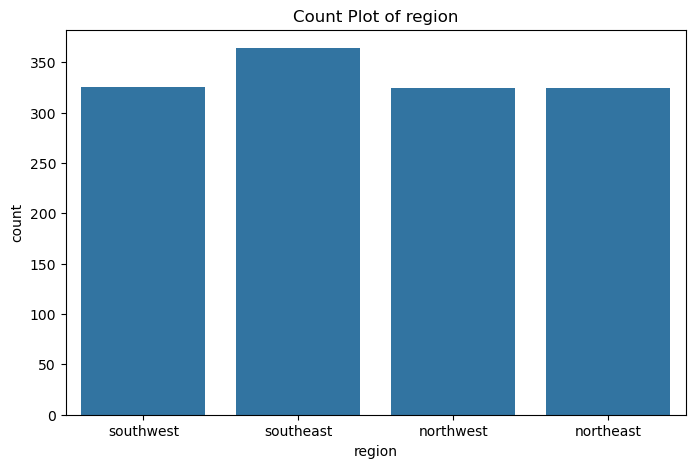

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
region
southeast    27.225131
southwest    24.308153
northwest    24.233358
northeast    24.233358
Name: proportion, dtype: float64


In [667]:
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, data=data)
    plt.title(f'Count Plot of {col}')
    plt.show()
    print(data[col].value_counts())
    print(data[col].value_counts(normalize=True)*100)

#### BIVariate Analysis

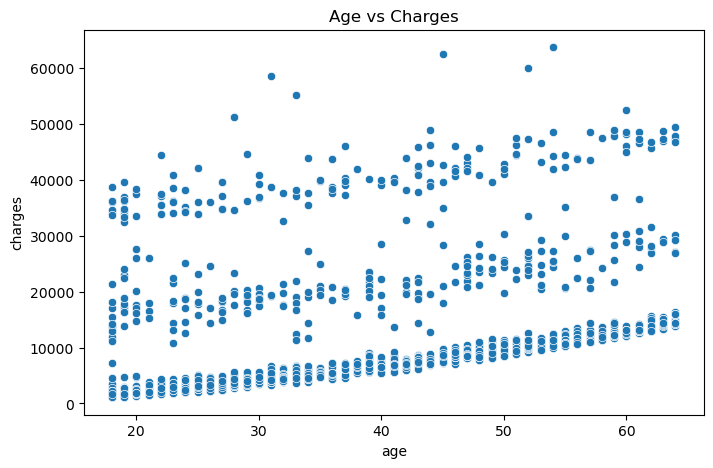

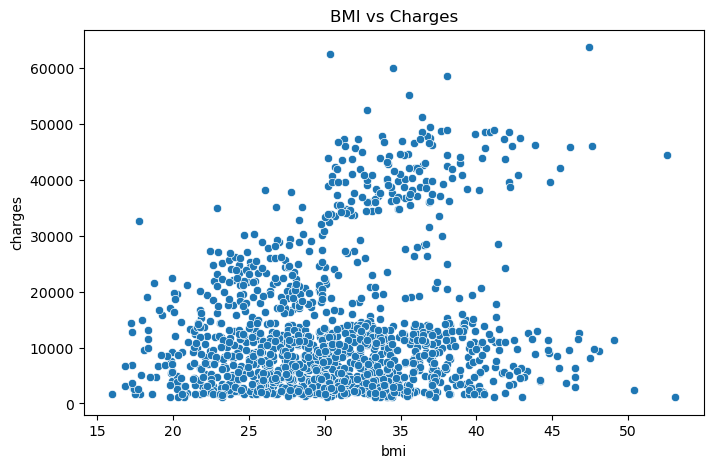

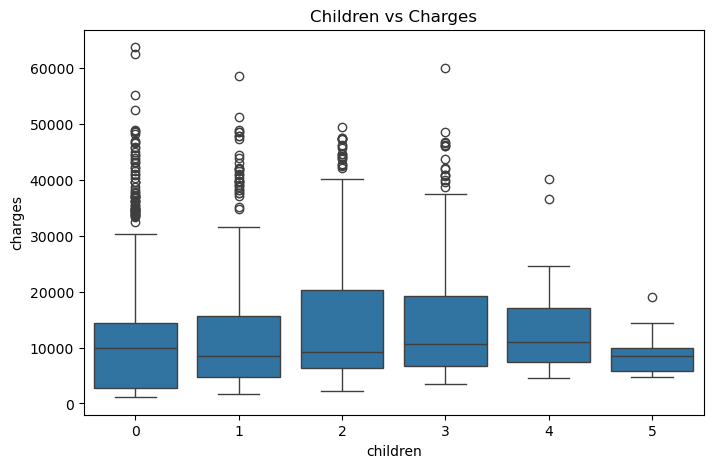

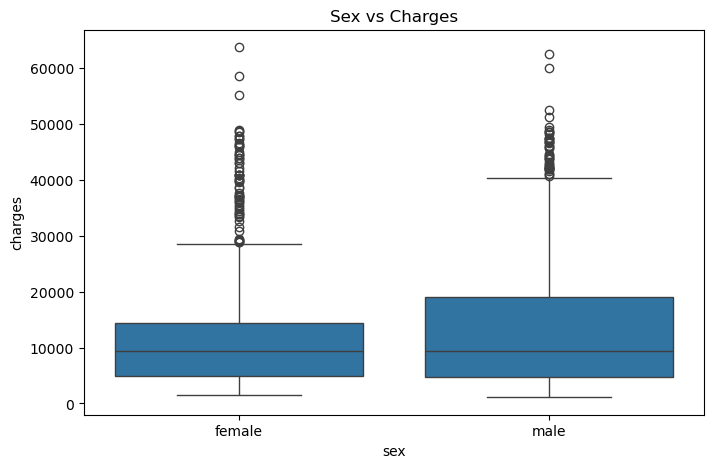

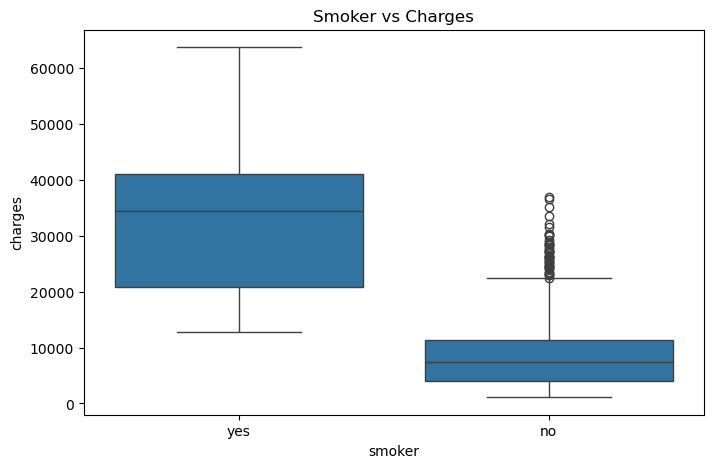

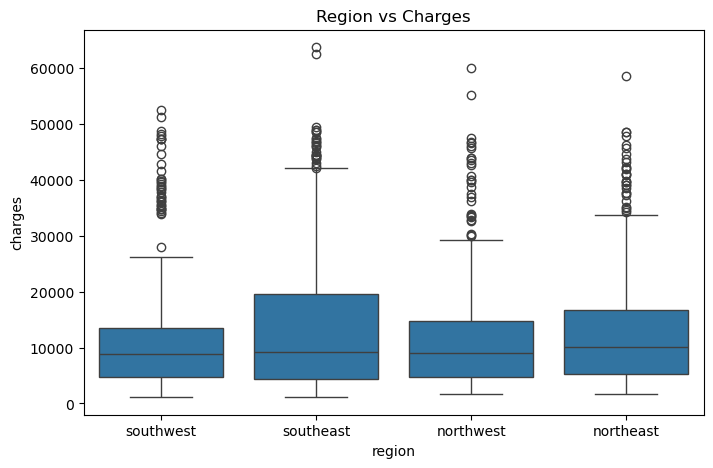

In [668]:
# Age vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=data)
plt.title('Age vs Charges')
plt.show()

# BMI vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=data)
plt.title('BMI vs Charges')
plt.show()

# Children vs Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='children', y='charges', data=data)
plt.title('Children vs Charges')
plt.show()

# Sex vs Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='sex', y='charges', data=data)
plt.title('Sex vs Charges')
plt.show()

# Smoker vs Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Smoker vs Charges')
plt.show()

# Region vs Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=data)
plt.title('Region vs Charges')
plt.show()

#### MultiVariate Analysis

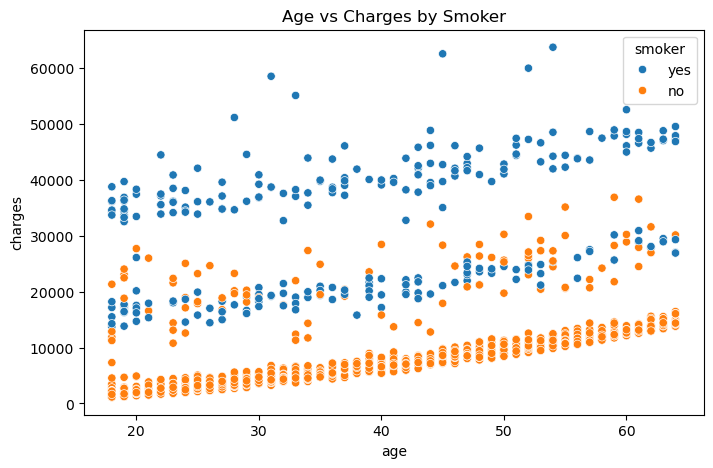

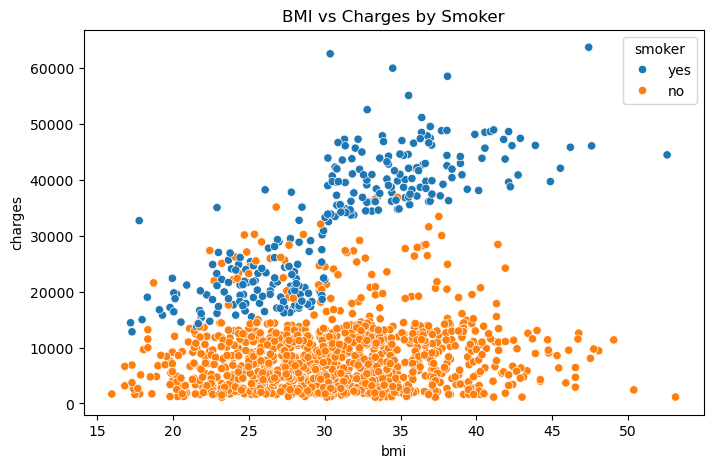

In [669]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age',y='charges',hue='smoker',data=data)
plt.title('Age vs Charges by Smoker')
plt.show()
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi',y='charges',hue='smoker',data=data)
plt.title('BMI vs Charges by Smoker')
plt.show()

# Feature Scaling

In [670]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [671]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [672]:
X = data.drop(['charges'],axis=1)
Y = data['charges']

In [673]:
X=pd.get_dummies(X,columns=["sex","smoker","region"],drop_first=True)

In [674]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [675]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [676]:
X

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,True,False,True,False,False
1334,18,31.920,0,False,False,False,False,False
1335,18,36.850,0,False,False,False,True,False
1336,21,25.800,0,False,False,False,False,True


In [677]:
Y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1337, dtype: float64

In [678]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

##### Linear Regression

In [679]:
linear = LinearRegression()
linear.fit(X_train,Y_train)

LinearRegression()

In [680]:
Y_pred_lin = linear.predict(X_test)


R2 score : 0.8069287081198011

Mean Absolute Error :  4177.045561036319


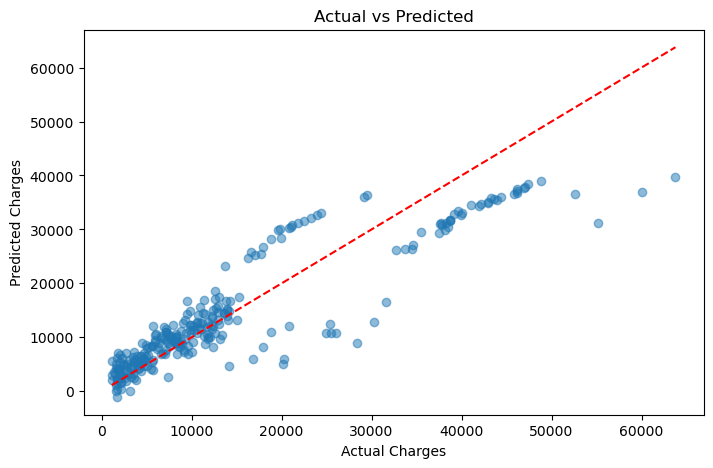

In [681]:
from sklearn.metrics import r2_score,mean_absolute_error
print('\nR2 score :',r2_score(Y_test,Y_pred_lin))
print('\nMean Absolute Error : ',mean_absolute_error(Y_test,Y_pred_lin))

# Visualize predictions vs actual
plt.figure(figsize=(8,5))
plt.scatter(Y_test, Y_pred_lin, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted')
plt.show()

##### Random Forest Regression

In [692]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=800,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1)
regressor.fit(X_train,Y_train)

RandomForestRegressor(n_estimators=800, n_jobs=-1, random_state=42)

In [693]:
Y_pred_for = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((Y_pred_for.reshape(-1, 1),Y_test.to_numpy().reshape(-1, 1)),axis=1))

[[ 9338.28  8688.86]
 [ 9737.5   5708.87]
 [12338.04 11436.74]
 [43083.54 38746.36]
 [ 6546.05  4463.21]
 [ 9973.23  9304.7 ]
 [38303.46 38511.63]
 [ 2355.64  2150.47]
 [10493.77  7345.73]
 [11005.86 10264.44]
 [14136.37 13415.04]
 [24005.61 24393.62]
 [42844.99 37607.53]
 [15063.86 13063.88]
 [ 6153.08 24915.05]
 [ 9830.47  8027.97]
 [ 7364.06  1980.07]
 [39577.6  38709.18]
 [ 5960.82  3484.33]
 [ 5180.51  3947.41]
 [ 4408.04  1880.07]
 [20356.15 20773.63]
 [10440.1   9800.89]
 [21444.15 21082.16]
 [39206.86 55135.4 ]
 [18916.72  3579.83]
 [43250.22 43896.38]
 [45804.09 52590.83]
 [10425.91  9778.35]
 [12605.79 10736.87]
 [ 4151.99  4347.02]
 [ 9311.66  9048.03]
 [ 3346.9   1711.03]
 [14472.14 12333.83]
 [47481.32 63770.43]
 [10033.18  9872.7 ]
 [ 7821.9   4687.8 ]
 [ 5600.81  5693.43]
 [23841.32 21195.82]
 [ 8978.59  8233.1 ]
 [ 2396.64  2755.02]
 [21066.19 19798.05]
 [41588.26 42124.52]
 [ 9482.12  9964.06]
 [ 9136.5   9193.84]
 [ 3826.6   3161.45]
 [ 2668.04  2217.6 ]
 [ 7996.76  7

In [695]:
r2_score(Y_test,Y_pred_for)

0.8814401609633332

##### SVR


In [685]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

sc_x = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_x.fit_transform(X_train)
X_test_scaled = sc_x.transform(X_test)

Y_train_scaled = sc_y.fit_transform(
    np.array(Y_train).reshape(-1,1)
)

In [686]:
svr = SVR(kernel='rbf',C=100,gamma=0.1,epsilon=0.1)
svr.fit(X_train_scaled, Y_train_scaled.ravel())


SVR(C=100, gamma=0.1)

In [687]:
y_pred_svr = sc_y.inverse_transform(
    svr.predict(X_test_scaled).reshape(-1,1)
).flatten()
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_svr.reshape(len(y_pred_svr),1), Y_test.to_numpy().reshape(len(Y_test),1)),1))

[[ 9.03e+03  8.69e+03]
 [ 1.40e+04  5.71e+03]
 [ 1.24e+04  1.14e+04]
 [ 3.34e+04  3.87e+04]
 [ 5.67e+03  4.46e+03]
 [ 9.30e+03  9.30e+03]
 [ 5.81e+04  3.85e+04]
 [ 3.24e+03  2.15e+03]
 [ 8.26e+03  7.35e+03]
 [ 1.09e+04  1.03e+04]
 [ 1.43e+04  1.34e+04]
 [ 2.65e+04  2.44e+04]
 [ 3.54e+04  3.76e+04]
 [ 1.18e+04  1.31e+04]
 [ 5.74e+03  2.49e+04]
 [ 9.06e+03  8.03e+03]
 [ 2.84e+03  1.98e+03]
 [ 3.68e+04  3.87e+04]
 [ 4.39e+03  3.48e+03]
 [ 4.21e+03  3.95e+03]
 [ 3.12e+03  1.88e+03]
 [ 2.17e+04  2.08e+04]
 [ 8.00e+03  9.80e+03]
 [ 2.36e+04  2.11e+04]
 [ 5.20e+04  5.51e+04]
 [ 1.15e+04  3.58e+03]
 [ 4.10e+04  4.39e+04]
 [ 4.25e+04  5.26e+04]
 [ 1.04e+04  9.78e+03]
 [ 1.72e+04  1.07e+04]
 [ 4.43e+03  4.35e+03]
 [ 9.84e+03  9.05e+03]
 [ 6.75e+03  1.71e+03]
 [ 1.27e+04  1.23e+04]
 [ 3.80e+04  6.38e+04]
 [ 1.09e+04  9.87e+03]
 [ 1.81e+04  4.69e+03]
 [ 1.85e+03  5.69e+03]
 [ 2.08e+04  2.12e+04]
 [ 9.31e+03  8.23e+03]
 [ 1.88e+03  2.76e+03]
 [ 2.22e+04  1.98e+04]
 [ 4.47e+04  4.21e+04]
 [ 1.09e+04

In [696]:
print("R2 Score:", r2_score(Y_test, y_pred_svr))
print("MAE:", mean_absolute_error(Y_test, y_pred_svr))

R2 Score: 0.804941541024922
MAE: 3323.4389785189064


##### GBoost

In [698]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, Y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [699]:
y_pred_gbr = gbr.predict(X_test)
r2_gbr = r2_score(Y_test, y_pred_gbr)
print("GBoost R²:", r2_gbr)

GBoost R²: 0.8997631435695307


In [700]:
print("Linear Regression R2:", r2_score(Y_test, Y_pred_lin))
print("Random Forest R2:", r2_score(Y_test, Y_pred_for))
print("SVR R2:", r2_score(Y_test, y_pred_svr))
print("GBoost R2:",r2_score(Y_test,y_pred_gbr))

Linear Regression R2: 0.8069287081198011
Random Forest R2: 0.8814401609633332
SVR R2: 0.804941541024922
GBoost R2: 0.8997631435695307


In [690]:
X

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,True,False,True,False,False
1334,18,31.920,0,False,False,False,False,False
1335,18,36.850,0,False,False,False,True,False
1336,21,25.800,0,False,False,False,False,True


In [691]:
new_data = pd.DataFrame({
    'age': [18],
    'bmi': [33.700],
    'children': [1],
    'sex_male': True,
    'smoker_yes':False,
    'region_northwest':False,
    'region_southeast':True,
    'region_southwest':False
})
prediction = regressor.predict(new_data)
print(prediction)

[3027.18]


In [702]:
comparison_df = pd.DataFrame({
    'Actual': Y_test,
    'Linear Regression Predicted' : Y_pred_lin,
    'SVR_Predicted': y_pred_svr,
    'RandomForest_Predicted': Y_pred_for,
    'GBoost_Predicted':y_pred_gbr,
})
comparison_df

,Actual,Linear Regression Predicted,SVR_Predicted,RandomForest_Predicted,GBoost_Predicted
900,8688.85885,8143.693884,9032.131598,9338.277967,10090.324946
1064,5708.86700,5737.115683,14016.638718,9737.503395,8421.559754
1256,11436.73815,14369.314876,12378.045438,12338.042382,13276.707446
298,38746.35510,31745.513636,33428.637148,43083.539728,39105.290198
237,4463.20510,8962.386657,5669.397967,6546.050891,6440.781372
...,...,...,...,...,...
534,13831.11520,16753.406458,14538.092257,14365.343070,13643.574131
542,13887.20400,15274.565769,13880.573104,14636.382948,14210.680374
760,3925.75820,6454.699355,10770.765823,8180.936084,7233.268596
1284,47403.88000,38467.156720,53052.233078,47889.457559,50831.229467
